# Modeling2_LGBM_interpretation — 감성 보조피처 SHAP 해석

모델링1 `final_aic_features` 19개 + 뉴스 감성 4개(23개)로 LGBM을 전체 데이터에 학습하고,
SHAP으로 변수 효과를 분해한다. 특히 **감성 보조피처가 비선형/트리 모델에서 기여하는지**를 본다.

- 감성 4개의 SHAP 중요도 순위·방향, dependence plot
- OLS β(HC3) ↔ SHAP 비교 — OLS에서 무의미했던 감성이 LGBM에서 살아나는가


## 1. 설정 + 데이터

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lightgbm as lgb
import shap
from sklearn.metrics import r2_score, mean_squared_error
from IPython.display import display

warnings.filterwarnings("ignore")

OUT_DIR = Path("../outputs/modeling2")
cfg = json.load(open(OUT_DIR / "final_features_v2.json", encoding="utf-8"))
TARGET        = cfg["target"]
base_cols     = cfg["base_features"]
sentiment_all = cfg["sentiment_features"]
model_cols    = cfg["all_features"]
print("base:", len(base_cols), "| sentiment:", sentiment_all, "| 전체:", len(model_cols))


base: 19 | sentiment: ['sent_supply_7d', 'sent_demand_7d', 'sent_geopolitical_7d', 'sent_financial_7d'] | 전체: 23


In [2]:
# 데이터 로드 + merge (전체 데이터)
sent_df = pd.read_csv("../data/Sentiment_Final/sentiment_avg_7d_final.csv", parse_dates=["date"])
base_df = pd.read_csv("../data/Finance_Final/dataset4_derived_full_with_dummies.csv", parse_dates=["date"])
sent_keep = ["date"] + [c for c in sent_df.columns if c.startswith("sent_")]

df_model = (base_df.merge(sent_df[sent_keep], on="date", how="inner")
                   .sort_values("date").reset_index(drop=True))
df_model = df_model[["date"] + model_cols + [TARGET]].dropna().reset_index(drop=True)

X = df_model[model_cols].copy()
y = df_model[TARGET].copy()
print("전체 표본:", len(df_model), "| X:", X.shape)


전체 표본: 4547 | X: (4547, 23)


## 2. LGBM 학습 (전체 데이터, 튜닝 없음)

In [3]:
lgbm = lgb.LGBMRegressor(
    n_estimators=300, learning_rate=0.05, num_leaves=31,
    random_state=42, verbosity=-1,
)
lgbm.fit(X, y)
pred = lgbm.predict(X)
print(f"in-sample R²  : {r2_score(y, pred):.4f}")
print(f"in-sample RMSE: {np.sqrt(mean_squared_error(y, pred)):.4f}")


in-sample R²  : 0.5563
in-sample RMSE: 1.3603


## 3. SHAP 값 계산

In [4]:
explainer = shap.TreeExplainer(lgbm)
shap_arr = np.array(explainer.shap_values(X))
print("shap_values shape:", shap_arr.shape)
print("expected_value   :", explainer.expected_value)


shap_values shape: (4547, 23)
expected_value   : 0.0003782705088593684


## 4. SHAP 요약 표

In [5]:
shap_summary = pd.DataFrame({
    "variable": model_cols,
    "is_sentiment": [v in sentiment_all for v in model_cols],
    "mean_abs_shap": np.abs(shap_arr).mean(axis=0),
    "mean_shap_signed": shap_arr.mean(axis=0),
    "sign_positive_ratio": (shap_arr > 0).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
shap_summary["rank"] = np.arange(1, len(shap_summary) + 1)

display(shap_summary.round(5))
print("\n감성 보조피처 SHAP 순위:")
display(shap_summary[shap_summary["is_sentiment"]][["rank","variable","mean_abs_shap","mean_shap_signed"]]
        .round(5).reset_index(drop=True))


,variable,is_sentiment,mean_abs_shap,mean_shap_signed,sign_positive_ratio,rank
0,OilPrice,False,0.14400,-0.00120,0.45766,1
1,MA_ratio,False,0.10702,0.00727,0.37431,2
2,oil_diff_lag1,False,0.10481,0.00139,0.50759,3
3,VIX,False,0.09035,-0.00186,0.38311,4
4,TreasuryYield,False,0.08074,-0.00153,0.69035,5
5,OilInventories,False,0.08069,0.00146,0.53178,6
6,OPECProduction,False,0.07869,-0.00680,0.55971,7
7,RealInterestRate,False,0.06628,0.00064,0.56873,8
8,CPE,False,0.06619,0.00042,0.57730,9
9,sent_supply_7d,True,0.06609,0.00011,0.50495,10



감성 보조피처 SHAP 순위:


,rank,variable,mean_abs_shap,mean_shap_signed
0,10,sent_supply_7d,0.06609,0.00011
1,11,sent_financial_7d,0.05325,-0.00031
2,12,sent_demand_7d,0.05256,0.00138
3,14,sent_geopolitical_7d,0.04574,0.00077


## 5. SHAP 시각화

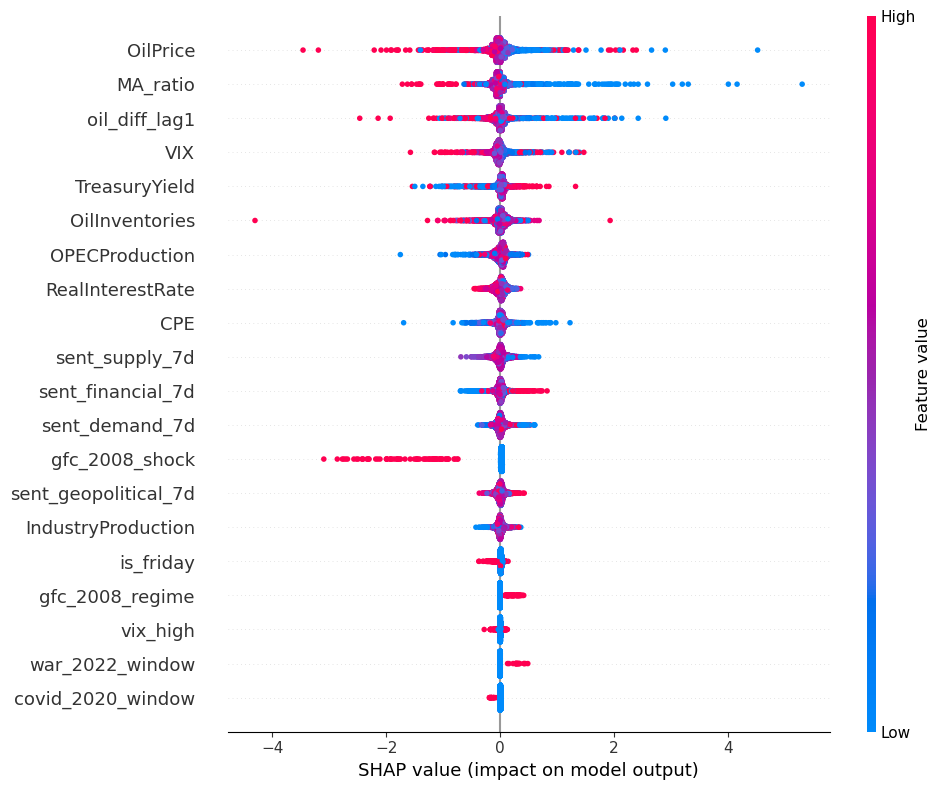

In [6]:
shap.summary_plot(shap_arr, X, show=False, plot_size=(10, 8))
fig = plt.gcf(); fig.tight_layout()
fig.savefig(OUT_DIR / "shap2_summary.png", dpi=150, bbox_inches="tight")
plt.show()


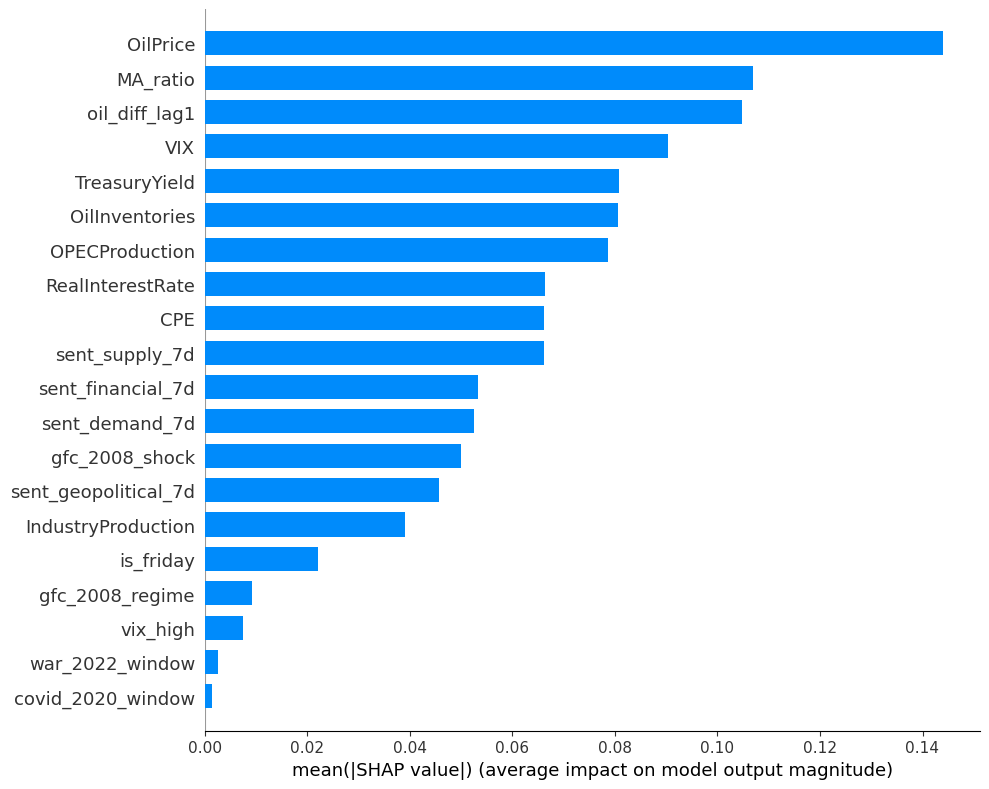

In [7]:
shap.summary_plot(shap_arr, X, plot_type="bar", show=False, plot_size=(10, 8))
fig = plt.gcf(); fig.tight_layout()
fig.savefig(OUT_DIR / "shap2_summary_bar.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. 감성 보조피처 집중 분석

감성 4개의 SHAP dependence plot — 감성점수 수준에 따라 LGBM 기여가 어떻게 달라지는지 본다.

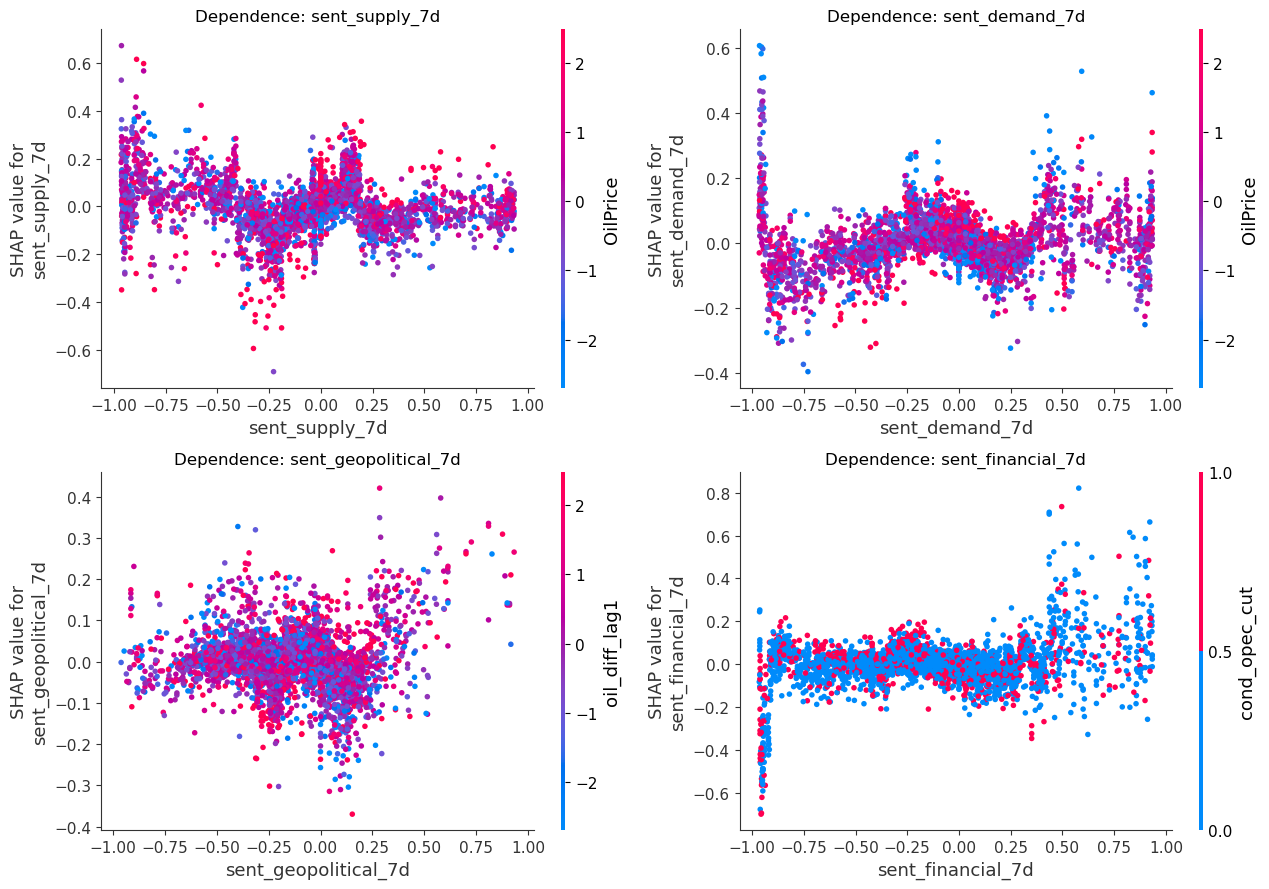

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
for i, var in enumerate(sentiment_all):
    shap.dependence_plot(var, shap_arr, X, ax=axes[i], show=False, interaction_index="auto")
    axes[i].set_title(f"Dependence: {var}", fontsize=12)
fig.tight_layout()
fig.savefig(OUT_DIR / "shap2_dependence_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. OLS β(HC3) ↔ SHAP 비교

In [9]:
ols = pd.read_csv(OUT_DIR / "ols2_interpretation_coefficients.csv")
ols.columns = [c.lstrip("\ufeff") for c in ols.columns]
ols["sig_OLS"]  = ols["p_HC3"] < 0.05
ols["sign_OLS"] = np.where(ols["std_beta"] >= 0, "+", "-")

shap_m = shap_summary.rename(columns={"rank": "rank_shap"}).copy()
shap_m["sign_SHAP"] = np.where(shap_m["mean_shap_signed"] >= 0, "+", "-")

cmp = ols[["variable","is_sentiment","std_beta","p_HC3","sig_OLS","sign_OLS"]].merge(
    shap_m[["variable","mean_abs_shap","rank_shap","sign_SHAP"]], on="variable", how="inner")
cmp["sign_match"] = cmp["sign_OLS"] == cmp["sign_SHAP"]

top_n = max(4, len(cmp) // 3)
shap_top = set(cmp.sort_values("mean_abs_shap", ascending=False).head(top_n)["variable"])
beta_top = set(cmp.assign(ab=cmp["std_beta"].abs())
                  .sort_values("ab", ascending=False).head(top_n)["variable"])

def classify(r):
    shap_big, beta_big = r["variable"] in shap_top, r["variable"] in beta_top
    if (not r["sig_OLS"]) and shap_big:   return "순수 비선형 효과"
    if not r["sign_match"]:               return "상호작용 의심"
    if shap_big and beta_big:             return "견고한 효과"
    if shap_big and not beta_big:         return "비선형 추가 효과"
    if beta_big and not shap_big:         return "선형 효과 위주"
    return "약한 효과"

cmp["case"] = cmp.apply(classify, axis=1)
cmp = cmp.sort_values("rank_shap").reset_index(drop=True)
display(cmp.round(5))

print("\n===== 감성 보조피처 OLS↔SHAP 비교 =====")
display(cmp[cmp["is_sentiment"]][["variable","std_beta","p_HC3","sig_OLS",
                                  "mean_abs_shap","rank_shap","sign_match","case"]]
        .round(5).reset_index(drop=True))


,variable,is_sentiment,std_beta,p_HC3,sig_OLS,sign_OLS,mean_abs_shap,rank_shap,sign_SHAP,sign_match,case
0,OilPrice,False,-0.32342,0.26233,False,-,0.14400,1,-,True,순수 비선형 효과
1,MA_ratio,False,-0.28685,0.14512,False,-,0.10702,2,+,False,순수 비선형 효과
2,oil_diff_lag1,False,-0.14021,0.04869,True,-,0.10481,3,+,False,상호작용 의심
3,VIX,False,-0.05907,0.17834,False,-,0.09035,4,-,True,순수 비선형 효과
4,TreasuryYield,False,0.06694,0.25948,False,+,0.08074,5,-,False,순수 비선형 효과
5,OilInventories,False,-0.01805,0.75959,False,-,0.08069,6,+,False,순수 비선형 효과
6,OPECProduction,False,-0.11227,0.08466,False,-,0.07869,7,-,True,순수 비선형 효과
7,RealInterestRate,False,-0.06012,0.09050,False,-,0.06628,8,+,False,상호작용 의심
8,CPE,False,-0.21969,0.06860,False,-,0.06619,9,+,False,상호작용 의심
9,sent_supply_7d,True,-0.00587,0.84443,False,-,0.06609,10,+,False,상호작용 의심



===== 감성 보조피처 OLS↔SHAP 비교 =====


,variable,std_beta,p_HC3,sig_OLS,mean_abs_shap,rank_shap,sign_match,case
0,sent_supply_7d,-0.00587,0.84443,False,0.06609,10,False,상호작용 의심
1,sent_financial_7d,0.03067,0.36298,False,0.05325,11,False,상호작용 의심
2,sent_demand_7d,0.00188,0.94567,False,0.05256,12,True,약한 효과
3,sent_geopolitical_7d,-0.00346,0.92275,False,0.04574,14,False,상호작용 의심


## 8. 저장

In [10]:
shap_summary.to_csv(OUT_DIR / "lgbm2_shap_summary.csv", index=False)
cmp.to_csv(OUT_DIR / "interpretation2_compare.csv", index=False)
np.save(OUT_DIR / "shap2_values.npy", shap_arr)

print("저장 완료:")
for fn in ["lgbm2_shap_summary.csv", "interpretation2_compare.csv", "shap2_values.npy",
           "shap2_summary.png", "shap2_summary_bar.png", "shap2_dependence_sentiment.png"]:
    print(" -", OUT_DIR / fn)


저장 완료:
 - ../outputs/modeling2/lgbm2_shap_summary.csv
 - ../outputs/modeling2/interpretation2_compare.csv
 - ../outputs/modeling2/shap2_values.npy
 - ../outputs/modeling2/shap2_summary.png
 - ../outputs/modeling2/shap2_summary_bar.png
 - ../outputs/modeling2/shap2_dependence_sentiment.png
